<a href="https://colab.research.google.com/github/Sagar122198/ML/blob/main/ML%20project%20demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [6]:
def importdata():
    url = "student_placement.csv"
    balance_data = pd.read_csv(url, header=0)
    print("Dataset Length:", len(balance_data))
    print("Dataset Shape:", balance_data.shape)
    print("Dataset Head:\n", balance_data.head())
    return balance_data

In [7]:
def splitdataset(balance_data):
    X = balance_data.iloc[:, 1:5].values
    Y = balance_data.iloc[:, 0].values
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)
    return X, Y, X_train, X_test, y_train, y_test

In [8]:
def train_using_gini(X_train, y_train):
    clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_gini.fit(X_train, y_train)
    return clf_gini

In [9]:
def train_using_entropy(X_train, y_train):
    clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_entropy.fit(X_train, y_train)
    return clf_entropy

In [10]:
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

In [11]:
def cal_accuracy(y_test, y_pred):
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [12]:
def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

In [14]:
if __name__ == "__main__":

    data = importdata()

    # Import LabelEncoder as it's needed for the target variable
    from sklearn.preprocessing import LabelEncoder

    # --- Data Preprocessing for Features (X) ---
    # Identify initial feature columns based on the original splitdataset's iloc[:, 1:5]
    # which correspond to 'age', 'gender', 'cgpa', 'branch'
    feature_cols_raw = ['age', 'gender', 'cgpa', 'branch']
    X_df = data[feature_cols_raw].copy()

    # Apply one-hot encoding to categorical features: 'gender' and 'branch'
    X_df = pd.get_dummies(X_df, columns=['gender', 'branch'], drop_first=True)

    # Store feature names for potential plotting later
    feature_names = X_df.columns.tolist()

    # --- Data Preprocessing for Target (Y) ---
    # The original splitdataset uses iloc[:, 0] for Y, which is 'student_id'.
    # For a placement prediction task, 'placement_status' is the appropriate target.
    # 'placement_status' is also categorical ('Placed', 'Not Placed'), so it needs encoding.
    target_col = 'placement_status'
    le = LabelEncoder()
    Y_encoded = le.fit_transform(data[target_col])
    class_names = le.classes_.tolist() # Store class names for potential plotting later

    # --- Splitting the dataset ---
    # Convert X_df to a numpy array to match the type expected by the original functions (if they strictly rely on it).
    # sklearn models can often handle pandas DataFrames directly, but explicit conversion ensures compatibility.
    X_processed = X_df.values

    # Y_encoded is already a numpy array from LabelEncoder.
    Y_true_target = Y_encoded

    X_train, X_test, y_train, y_test = train_test_split(X_processed, Y_true_target, test_size=0.3, random_state=100)

    print("\n----- Training Using Gini -----")
    clf_gini = train_using_gini(X_train, y_train)
    y_pred_gini = prediction(X_test, clf_gini)
    cal_accuracy(y_test, y_pred_gini)
    # Uncomment the line below if you wish to visualize the decision tree
    # plot_decision_tree(clf_gini, feature_names, class_names)

    print("\n----- Training Using Entropy -----")
    clf_entropy = train_using_entropy(X_train, y_train)
    y_pred_entropy = prediction(X_test, clf_entropy)
    cal_accuracy(y_test, y_pred_entropy)
    # Uncomment the line below if you wish to visualize the decision tree
    # plot_decision_tree(clf_entropy, feature_names, class_names)


Dataset Length: 100000
Dataset Shape: (100000, 26)
Dataset Head:
    student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             

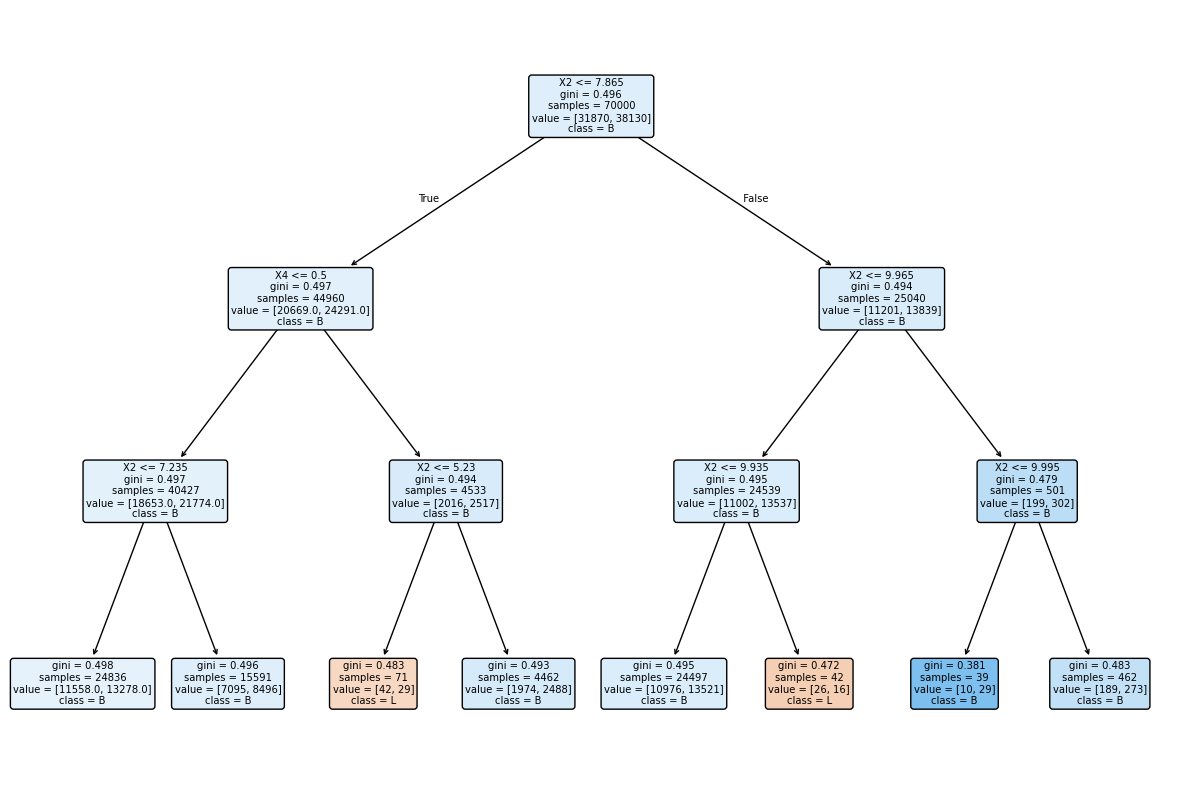

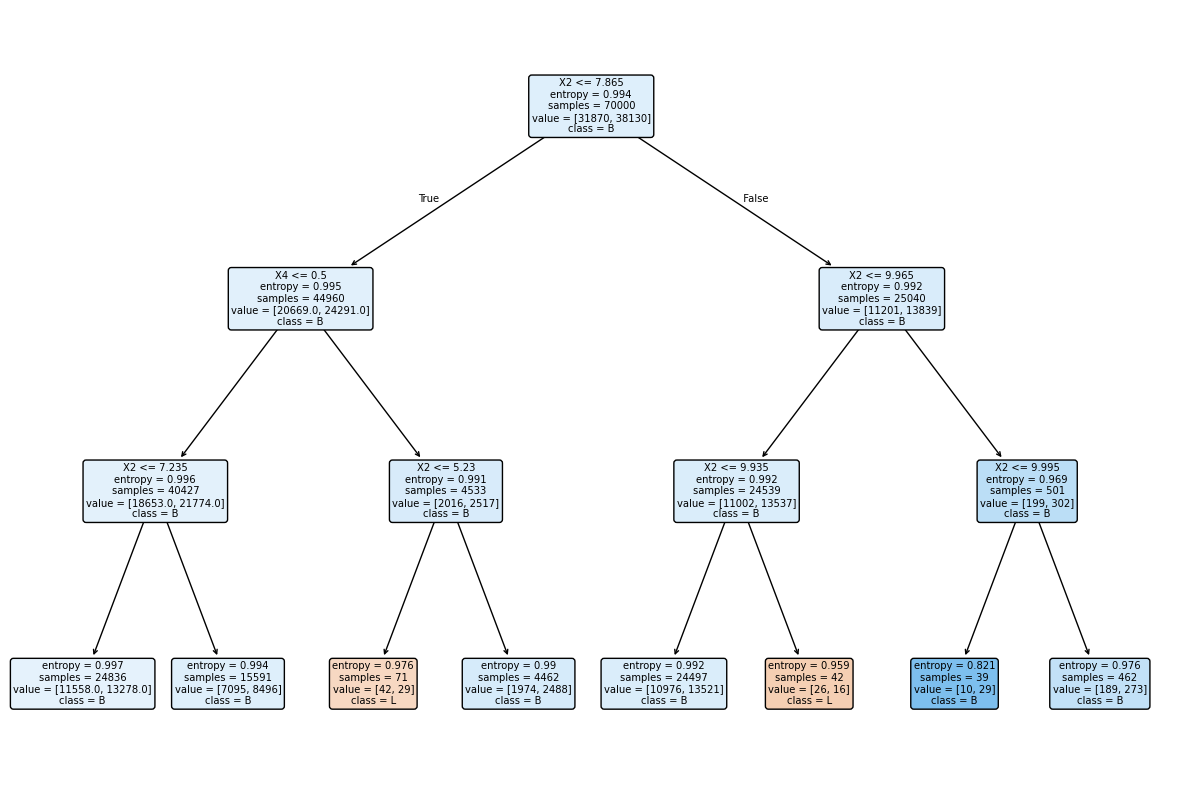

In [15]:
plot_decision_tree(clf_gini, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])

plot_decision_tree(clf_entropy, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])